# Industrial Chignon Detection -- Training Pipeline
# ResNet18-UNet . YOLOv8m-seg . YOLOv11m-seg
# Adapted for Kaggle T4 x2 (2x 16GB VRAM)


In [1]:
# T4 (sm_75) is supported by Kaggle's default PyTorch -- no reinstall needed
!pip install -q ultralytics --no-deps
!pip install -q psutil py-cpuinfo thop seaborn
import warnings; warnings.filterwarnings('ignore')

import torch
n_gpus = torch.cuda.device_count()
print(f'PyTorch {torch.__version__}, CUDA {torch.version.cuda}')
print(f'Multi-GPU: {n_gpus} GPUs available')


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 29.3 MB/s eta 0:00:00
PyTorch 2.10.0+cu128, CUDA 12.8
Multi-GPU: 2 GPUs available


In [2]:
import os, sys, json, copy, glob, time, random, shutil, threading, csv
from pathlib import Path
from datetime import datetime
from typing import Dict, List, Optional, Tuple, Any, Callable
from dataclasses import dataclass, field, asdict
from collections import defaultdict

import cv2
import numpy as np
from PIL import Image
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.cuda.amp import autocast, GradScaler
from torch.utils.data import Dataset, DataLoader
from torchvision import models
from tqdm import tqdm
import psutil
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.ticker import MaxNLocator

try:
    import pynvml; pynvml.nvmlInit(); PYNVML_AVAILABLE = True
except:
    PYNVML_AVAILABLE = False

# ── Paths ──────────────────────────────────────────────────
INPUT_DIR  = Path("/kaggle/input/datasets/mryoussefmahdi")   # dataset
OUTPUT_DIR = Path("/kaggle/working/outputs")            # results
DATA_DIR   = INPUT_DIR / "stator-data-1"                # raw images + json
AUG_DIR    = OUTPUT_DIR / "augmented_data"
YOLO_DIR   = OUTPUT_DIR / "yolo_dataset"
RESULTS_DIR = OUTPUT_DIR / "results"
PLOTS_DIR   = RESULTS_DIR / "plots"
LOG_DIR     = RESULTS_DIR / "training_logs"
CHECKPOINTS = RESULTS_DIR / "checkpoints"

for d in [OUTPUT_DIR, AUG_DIR, YOLO_DIR, RESULTS_DIR, PLOTS_DIR, LOG_DIR, CHECKPOINTS]:
    d.mkdir(parents=True, exist_ok=True)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
NUM_GPUS = torch.cuda.device_count() if DEVICE == 'cuda' else 0
SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed(SEED)
torch.backends.cudnn.deterministic = True; torch.backends.cudnn.benchmark = False
print(f"Device: {DEVICE}")
print(f"Input:  {INPUT_DIR}")
print(f"Output: {OUTPUT_DIR}")
print(f"GPUs:   {NUM_GPUS}")


Device: cuda
Input:  /kaggle/input/datasets/mryoussefmahdi
Output: /kaggle/working/outputs
GPUs:   2


## 1. Dataset & Data Loaders

This section defines the core PyTorch DataLoaders. It dynamically pairs raw images with their corresponding `labelme` JSON annotations, rasterizes the polygon shapes into pixel-level masks, and gracefully splits the corpus into training, validation, and test sets.


In [3]:

LABELS = ["background", "file"]
NUM_CLASSES = len(LABELS)

@dataclass
class Sample:
    image_path: str
    annotation_path: str

def load_labelme_annotation(json_path):
    with open(json_path, 'r') as f:
        return json.load(f)

def create_mask_from_shapes(shapes, image_height, image_width,
                            class_mapping=None, label_filter=None):
    if class_mapping is None:
        class_mapping = {l: i for i, l in enumerate(LABELS)}
    mask = np.zeros((image_height, image_width), dtype=np.uint8)
    contours = []
    for shape in shapes:
        shape_type = shape.get("shape_type", "")
        label = shape.get("label", "unknown")
        points = np.array(shape.get("points", []), dtype=np.float32)
        if len(points) < 2: continue
        if label_filter is not None and label not in label_filter: continue
        class_idx = class_mapping.get(label, 1)
        if class_idx == 0: continue
        pts = points.astype(np.int32)
        if shape_type == "polygon":
            cv2.fillPoly(mask, [pts], class_idx); contours.append(pts)
        elif shape_type == "linestrip":
            if len(pts) >= 3:
                closed = np.vstack([pts, pts[0:1]])
                cv2.fillPoly(mask, [closed], class_idx); contours.append(closed)
        elif shape_type == "line" and len(pts) >= 2:
            cv2.line(mask, tuple(pts[0]), tuple(pts[1]), class_idx, 3)
            contours.append(pts)
    return mask, contours

def get_all_samples(root_path):
    # Robust pairing: use set intersection of image and JSON basenames
    all_jsons = sorted(glob.glob(os.path.join(root_path, "*.json")))
    all_imgs = []
    for ext in ["*.png", "*.jpg", "*.jpeg"]:
        all_imgs.extend(glob.glob(os.path.join(root_path, ext)))
    json_bases = {os.path.splitext(os.path.basename(j))[0]: j for j in all_jsons}
    img_bases = {}
    for ip in all_imgs:
        base = os.path.splitext(os.path.basename(ip))[0]
        if base not in img_bases:
            img_bases[base] = ip
    paired_bases = sorted(set(json_bases.keys()) & set(img_bases.keys()))
    orphan_imgs = set(img_bases.keys()) - set(json_bases.keys())
    orphan_jsons = set(json_bases.keys()) - set(img_bases.keys())
    if orphan_imgs:
        print(f"  [WARN] {len(orphan_imgs)} images without JSON (skipped)")
    if orphan_jsons:
        print(f"  [WARN] {len(orphan_jsons)} JSONs without image (skipped)")
    samples = [Sample(img_bases[b], json_bases[b]) for b in paired_bases]
    print(f"  Paired samples: {len(samples)}")
    return samples

def split_dataset(samples, train_r=0.70, val_r=0.15, test_r=0.15, seed=SEED):
    random.seed(seed)
    s = samples.copy(); random.shuffle(s)
    n = len(s); nt = int(n * train_r); nv = nt + int(n * val_r)
    return s[:nt], s[nt:nv], s[nv:]

class IndustrialDataset(Dataset):
    def __init__(self, samples, target_size=(512,512), label_filter=None):
        self.samples = samples
        self.target_size = target_size
        self.label_filter = label_filter
    def __len__(self): return len(self.samples)
    def __getitem__(self, idx):
        s = self.samples[idx]
        img = cv2.cvtColor(cv2.imread(s.image_path), cv2.COLOR_BGR2RGB)
        ann = load_labelme_annotation(s.annotation_path)
        mask, _ = create_mask_from_shapes(
            ann["shapes"], ann["imageHeight"], ann["imageWidth"],
            label_filter=self.label_filter)
        if self.target_size:
            img = cv2.resize(img, (self.target_size[1], self.target_size[0]))
            mask = cv2.resize(mask, (self.target_size[1], self.target_size[0]),
                              interpolation=cv2.INTER_NEAREST)
        return {"image": img, "mask": mask, "image_path": s.image_path}

def make_collate(batch):
    return {
        "image": np.stack([b["image"] for b in batch]),
        "mask":  np.stack([b["mask"]  for b in batch]),
        "image_path": [b["image_path"] for b in batch],
    }

def create_dataloaders(root_path, batch_size=8, target_size=(512,512), label_filter=None):
    samples = get_all_samples(root_path)
    tr, va, te = split_dataset(samples)
    print(f"Split: Train={len(tr)}, Val={len(va)}, Test={len(te)}")
    trd = IndustrialDataset(tr, target_size, label_filter)
    vad = IndustrialDataset(va, target_size, label_filter)
    ted = IndustrialDataset(te, target_size, label_filter)
    return (DataLoader(trd, batch_size=batch_size, shuffle=True,  num_workers=2, collate_fn=make_collate, drop_last=True),
            DataLoader(vad, batch_size=batch_size, shuffle=False, num_workers=2, collate_fn=make_collate),
            DataLoader(ted, batch_size=batch_size, shuffle=False, num_workers=2, collate_fn=make_collate))
print(" Dataset classes ready")


 Dataset classes ready


## 2. Robust Data Augmentation

To maximize model generalization on small datasets, this block configures a suite of offline augmentation techniques. We dynamically simulate edge cases like metallic light reflections (SunFlare), color shifts (ColorJitter), and geometric transformations.


In [4]:

def identity_image(img): return img.copy()
def rotate90_image(img):  return cv2.rotate(img, cv2.ROTATE_90_CLOCKWISE)
def rotate180_image(img): return cv2.rotate(img, cv2.ROTATE_180)
def rotate270_image(img): return cv2.rotate(img, cv2.ROTATE_90_COUNTERCLOCKWISE)
def flip_horizontal_image(img): return cv2.flip(img, 1)

def identity_point(p, w, h): return p
def rotate90_point(p, w, h):  return [h - p[1] - 1, p[0]]
def rotate180_point(p, w, h): return [w - p[0] - 1, h - p[1] - 1]
def rotate270_point(p, w, h): return [p[1], w - p[0] - 1]
def flip_horizontal_point(p, w, h): return [w - p[0] - 1, p[1]]

def photo_identity(img): return img.copy()
def photo_brightness_up(img):   return cv2.convertScaleAbs(img, alpha=1.0, beta=35)
def photo_brightness_down(img): return cv2.convertScaleAbs(img, alpha=1.0, beta=-35)
def photo_contrast_up(img):     return cv2.convertScaleAbs(img, alpha=1.4, beta=-40)
def photo_gaussian_blur(img):   return cv2.GaussianBlur(img, (5,5), 1.2)
def photo_clahe(img):
    if len(img.shape)==3:
        lab=cv2.cvtColor(img,cv2.COLOR_BGR2LAB)
        lab[:,:,0]=cv2.createCLAHE(3.0,(8,8)).apply(lab[:,:,0])
        return cv2.cvtColor(lab,cv2.COLOR_LAB2BGR)
    return cv2.createCLAHE(3.0,(8,8)).apply(img)
def photo_gamma_dark(img):
    t=np.array([((i/255)**1.667)*255 for i in range(256)]).astype(np.uint8)
    return cv2.LUT(img,t)
def photo_gamma_bright(img):
    t=np.array([((i/255)**0.556)*255 for i in range(256)]).astype(np.uint8)
    return cv2.LUT(img,t)
def photo_lum_shift(img):
    if len(img.shape)==2: return cv2.convertScaleAbs(img,alpha=1.0,beta=20)
    hsv=cv2.cvtColor(img,cv2.COLOR_BGR2HSV).astype(np.int32)
    hsv[:,:,2]=np.clip(hsv[:,:,2]+20,0,255)
    return cv2.cvtColor(hsv.astype(np.uint8),cv2.COLOR_HSV2BGR)

GEO_TRANSFORMS = [
    ("orig",   identity_image,        identity_point),
    ("flipH",  flip_horizontal_image, flip_horizontal_point),
    ("rot90",  rotate90_image,        rotate90_point),
    ("rot180", rotate180_image,       rotate180_point),
    ("rot270", rotate270_image,       rotate270_point),
]
PHOTO_TRANSFORMS = [
    ("clean",       photo_identity),
    ("bright_up",   photo_brightness_up),
    ("bright_down", photo_brightness_down),
    ("contrast_up", photo_contrast_up),
    ("gauss_blur",  photo_gaussian_blur),
    ("clahe",       photo_clahe),
    ("gamma_dark",  photo_gamma_dark),
    ("gamma_bright",photo_gamma_bright),
    ("lum_shift",   photo_lum_shift),
]

def transform_annotation(ann, geo_name, point_fn, img_w, img_h, new_w, new_h):
    new_ann = copy.deepcopy(ann)
    new_ann["imageWidth"]  = new_w
    new_ann["imageHeight"] = new_h
    for shape in new_ann.get("shapes", []):
        shape["points"] = [point_fn(p, img_w, img_h) for p in shape["points"]]
    return new_ann

def run_augmentation(input_dir, output_dir):
    os.makedirs(output_dir, exist_ok=True)
    json_files = sorted(glob.glob(os.path.join(input_dir, "*.json")))
    total = 0
    for idx, jp in enumerate(json_files):
        base = os.path.splitext(jp)[0]
        ip = None
        for ext in [".png",".jpg",".jpeg"]:
            if os.path.exists(base+ext): ip = base+ext; break
        if ip is None: continue
        img = cv2.imread(ip)
        if img is None: continue
        h, w = img.shape[:2]
        with open(jp,'r') as f: ann = json.load(f)
        stem = Path(ip).stem
        for gn, gfn, gpfn in GEO_TRANSFORMS:
            gi = gfn(img)
            nh, nw = gi.shape[:2]
            ga = transform_annotation(ann, gn, gpfn, w, h, nw, nh)
            for pn, pfn in PHOTO_TRANSFORMS:
                pi = pfn(gi)
                name = f"{stem}_{gn}_{pn}"
                cv2.imwrite(os.path.join(output_dir, name+".png"), pi)
                with open(os.path.join(output_dir, name+".json"), 'w') as f:
                    json.dump(ga, f)
                total += 1
        if (idx+1) % 50 == 0: print(f"  [{idx+1}/{len(json_files)}]")
    print(f" Augmentation done: {total} samples from {len(json_files)} originals")

print(" Augmentation functions ready")


 Augmentation functions ready


## 2.1 Visualization: Augmentation Grid

Ensure transformations are visually sound before training.

In [ ]:
def visualize_augmentations(input_dir, num_samples=3):
    '''Visualizes original vs augmented data side-by-side using Matplotlib.'''
    if not os.path.exists(input_dir): return
    import glob, random
    files = glob.glob(os.path.join(input_dir, '*_clean.png'))
    if not files: return
    samples = random.sample(files, min(num_samples, len(files)))
    
    fig, axes = plt.subplots(len(samples), 3, figsize=(12, 4 * len(samples)))
    for i, orig_path in enumerate(samples):
        # The clean image
        orig_img = cv2.cvtColor(cv2.imread(orig_path), cv2.COLOR_BGR2RGB)
        # Find corresponding augments
        base_name = orig_path.replace('_clean.png', '')
        aug2_path = base_name + '_gamma_dark.png'
        aug3_path = base_name + '_color_jitter.png'
        # Fallbacks
        if not os.path.exists(aug3_path): aug3_path = base_name + '_clahe.png'
        
        axes[i, 0].imshow(orig_img); axes[i, 0].set_title('Clean Image')
        axes[i, 0].axis('off')
        
        if os.path.exists(aug2_path):
            a2 = cv2.cvtColor(cv2.imread(aug2_path), cv2.COLOR_BGR2RGB)
            axes[i, 1].imshow(a2); axes[i, 1].set_title('Augmentation (Gamma/Contrast)')
            axes[i, 1].axis('off')
            
        if os.path.exists(aug3_path):
            a3 = cv2.cvtColor(cv2.imread(aug3_path), cv2.COLOR_BGR2RGB)
            axes[i, 2].imshow(a3); axes[i, 2].set_title('Augmentation (Jitter/Clahe)')
            axes[i, 2].axis('off')
            
    plt.tight_layout(); 
    plt.suptitle('Data Augmentation Sanity Check Grid', y=1.02, fontsize=16)
    plt.show()

# visualize_augmentations(str(AUG_DIR), num_samples=2)


## 3. YOLO Dataset Preparation

This translates standard `.json` polygonal annotations into normalized `.txt` YOLOv8/v11 instance segmentation formats. It handles automatic directory structuring and builds the `data.yaml` manifest.


In [5]:

def labelme_to_yolo_seg(json_path, class_names=None):
    if class_names is None:
        class_names = [l for l in LABELS if l != 'background']
    with open(json_path,'r') as f: data = json.load(f)
    iw, ih = data.get('imageWidth',640), data.get('imageHeight',480)
    lines = []
    for shape in data.get('shapes',[]):
        st = shape.get('shape_type',''); label = shape.get('label','')
        if label not in class_names: continue
        pts = shape.get('points',[])
        if st=='polygon' and len(pts)<3: continue
        elif st=='linestrip':
            if len(pts)<3: continue
            pts = pts + [pts[0]]
        elif st=='line':
            if len(pts)<2: continue
            p1,p2 = np.array(pts[0]),np.array(pts[1])
            d=p2-p1; l=np.linalg.norm(d)
            if l==0: continue
            perp=np.array([-d[1],d[0]])/l*2
            pts=[(p1+perp).tolist(),(p2+perp).tolist(),(p2-perp).tolist(),(p1-perp).tolist()]
        else: continue
        cid = class_names.index(label)
        norm = []
        for x,y in pts: norm.extend([max(0,min(1,x/iw)), max(0,min(1,y/ih))])
        lines.append(f"{cid} " + " ".join(f"{v:.6f}" for v in norm))
    return lines

def prepare_yolo_dataset(source_dir, output_dir, train_r=0.7, val_r=0.15, test_r=0.15):
    src = Path(source_dir); out = Path(output_dir)
    pairs = []
    for jp in sorted(src.glob("*.json")):
        ip = jp.with_suffix('.jpg')
        if not ip.exists(): ip = jp.with_suffix('.png')
        if ip.exists(): pairs.append((ip, jp))
    print(f"Found {len(pairs)} pairs")
    random.seed(SEED); random.shuffle(pairs)
    nt = int(len(pairs)*train_r); nv = int(len(pairs)*val_r)
    splits = {'train': pairs[:nt], 'val': pairs[nt:nt+nv], 'test': pairs[nt+nv:]}
    class_names = [l for l in LABELS if l != 'background']
    for sn, sp in splits.items():
        idir = out/sn/'images'; ldir = out/sn/'labels'
        idir.mkdir(parents=True, exist_ok=True); ldir.mkdir(parents=True, exist_ok=True)
        for ip,jp in sp:
            shutil.copy2(ip, idir/ip.name)
            ylines = labelme_to_yolo_seg(str(jp), class_names)
            (ldir/(ip.stem+'.txt')).write_text('\n'.join(ylines))
        print(f"  {sn}: {len(sp)}")
    yaml_path = out/'data.yaml'
    yaml_path.write_text(f"path: {out.absolute()}\ntrain: train/images\nval: val/images\ntest: test/images\nnc: {len(class_names)}\nnames: {class_names}\n")
    print(f" YOLO dataset: {yaml_path}")
    return str(yaml_path)

print(" YOLO prep ready")


 YOLO prep ready


## 4. UNet-ResNet18 Architecture

We implement a state-of-the-art encoder-decoder network. It utilizes a pre-trained ResNet18 backbone for robust feature extraction and standard transposed convolutions for spatial recovery.


In [6]:

class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch, mid_ch=None):
        super().__init__()
        if mid_ch is None: mid_ch = out_ch
        self.double_conv = nn.Sequential(
            nn.Conv2d(in_ch, mid_ch, 3, padding=1, bias=False), nn.BatchNorm2d(mid_ch), nn.ReLU(True),
            nn.Conv2d(mid_ch, out_ch, 3, padding=1, bias=False), nn.BatchNorm2d(out_ch), nn.ReLU(True))
    def forward(self, x): return self.double_conv(x)

class Up(nn.Module):
    def __init__(self, in_ch, out_ch, bilinear=True):
        super().__init__()
        if bilinear:
            self.up = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
            self.conv = DoubleConv(in_ch, out_ch, in_ch // 2)
        else:
            self.up = nn.ConvTranspose2d(in_ch, in_ch//2, 2, stride=2)
            self.conv = DoubleConv(in_ch, out_ch)
    def forward(self, x1, x2):
        x1 = self.up(x1)
        dy = x2.size(2)-x1.size(2); dx = x2.size(3)-x1.size(3)
        x1 = F.pad(x1, [dx//2, dx-dx//2, dy//2, dy-dy//2])
        return self.conv(torch.cat([x2, x1], dim=1))

class UNetResNet18(nn.Module):
        # Initialize the state-of-the-art UNet Architecture powered by ResNet18
    def __init__(self, n_classes=4, pretrained=True):
        super().__init__()
        # Load pretrained ResNet backbone designed for efficient feature extraction
        resnet = models.resnet18(weights='IMAGENET1K_V1' if pretrained else None)
        self.encoder1 = nn.Sequential(resnet.conv1, resnet.bn1, resnet.relu)
        self.pool = resnet.maxpool
        self.encoder2 = resnet.layer1
        self.encoder3 = resnet.layer2
        self.encoder4 = resnet.layer3
        self.encoder5 = resnet.layer4
        self.up1 = Up(512+256, 256); self.up2 = Up(256+128, 128)
        self.up3 = Up(128+64, 64);   self.up4 = Up(64+64, 32)
        self.final_conv = nn.Sequential(
            nn.Conv2d(32,32,3,padding=1), nn.BatchNorm2d(32), nn.ReLU(True),
            nn.Conv2d(32, n_classes, 1))
    def forward(self, x):
        # --- Encoder Path (Downsampling) ---
        e1=self.encoder1(x); e1p=self.pool(e1)
        e2=self.encoder2(e1p); e3=self.encoder3(e2)
        e4=self.encoder4(e3);  e5=self.encoder5(e4)
        # --- Decoder Path (Upsampling + Skip Connections) ---
        d1=self.up1(e5,e4); d2=self.up2(d1,e3)
        d3=self.up3(d2,e2); d4=self.up4(d3,e1)
        d4=F.interpolate(d4, scale_factor=2, mode='bilinear', align_corners=True)
        return self.final_conv(d4)

print(" UNetResNet18 model ready")


 UNetResNet18 model ready


## 5. Combined Loss Functions

To tackle class imbalance (e.g., small bounding boxes vs large backgrounds), we combine standard Cross-Entropy Loss with Soft Dice Loss. This stabilizes training and explicitly optimizes the target Intersection-over-Union (IoU) metric.


In [7]:

class DiceLoss(nn.Module):
    def __init__(self, smooth=1.0): super().__init__(); self.smooth=smooth
    def forward(self, pred, target):
        pred=torch.sigmoid(pred).view(-1); target=target.view(-1)
        inter=(pred*target).sum()
        return 1-(2*inter+self.smooth)/(pred.sum()+target.sum()+self.smooth)

class MultiClassCombinedLoss(nn.Module):
    def __init__(self, num_classes=4, ce_w=0.5, dice_w=0.5):
        super().__init__(); self.nc=num_classes
        self.ce=nn.CrossEntropyLoss(); self.ce_w=ce_w; self.dice_w=dice_w
    def forward(self, pred, target):
        ce = self.ce(pred, target)
        ps = torch.softmax(pred.float(), dim=1)
        dl = torch.tensor(0.0, device=pred.device)
        for c in range(self.nc):
            pc=ps[:,c]; tc=(target==c).float()
            inter=(pc*tc).sum(); union=pc.sum()+tc.sum()
            dl += 1.0-(2*inter+1e-7)/(union+1e-7)
        dl /= self.nc
        return torch.clamp(self.ce_w*ce + self.dice_w*dl, 0, 100)

print(" Loss functions ready")


 Loss functions ready


## 6. Hardware Monitoring & Training Pipeline

This robust trainer object automates the training loop. It leverages PyTorch's `DataParallel` for multi-GPU execution, handles early-stopping, automatic checkpoint saving, and tracks real-time memory overhead using `psutil` and `pynvml`.


In [8]:

class HardwareMonitor:
    # Professional-grade thread to poll CPU/RAM/GPU states asynchronously
    def __init__(self, interval=0.5):
        self.interval=interval; self.running=False; self.thread=None
        self.cpu_s=[]; self.ram_s=[]; self.gpu_u=[]; self.gpu_m=[]; self.ts=[]
        self.gpu_handle=None
        if PYNVML_AVAILABLE:
            try: self.gpu_handle=pynvml.nvmlDeviceGetHandleByIndex(0)
            except: pass
    def start(self):
        self.running=True; self.cpu_s=[]; self.ram_s=[]; self.gpu_u=[]; self.gpu_m=[]; self.ts=[]
        self.thread=threading.Thread(target=self._loop, daemon=True); self.thread.start()
    def stop(self):
        self.running=False
        if self.thread: self.thread.join(1.0)
        return self.stats()
    def _loop(self):
        while self.running:
            try:
                self.cpu_s.append(psutil.cpu_percent(None))
                self.ram_s.append(psutil.virtual_memory().used/1024/1024)
                if self.gpu_handle and PYNVML_AVAILABLE:
                    u=pynvml.nvmlDeviceGetUtilizationRates(self.gpu_handle)
                    m=pynvml.nvmlDeviceGetMemoryInfo(self.gpu_handle)
                    self.gpu_u.append(u.gpu); self.gpu_m.append(m.used/1024/1024)
                elif torch.cuda.is_available():
                    self.gpu_m.append(torch.cuda.memory_allocated()/1024/1024); self.gpu_u.append(0)
                else:
                    self.gpu_u.append(0); self.gpu_m.append(0)
                self.ts.append(time.time())
                time.sleep(self.interval)
            except: pass
    def get_current(self):
        gm=torch.cuda.memory_allocated()/1024/1024 if torch.cuda.is_available() else 0
        return {'cpu_percent':psutil.cpu_percent(None),'ram_used_mb':psutil.virtual_memory().used/1024/1024,
                'gpu_utilization':0,'gpu_memory_mb':gm}
    def stats(self):
        def s(v): return {'mean':float(np.mean(v)) if v else 0,'max':float(np.max(v)) if v else 0}
        return {'cpu':s(self.cpu_s),'ram':s(self.ram_s),'gpu_util':s(self.gpu_u),'gpu_mem':s(self.gpu_m)}

@dataclass
class BatchMetrics:
    batch_idx:int; timestamp:float; loss:float
    forward_time_ms:float; backward_time_ms:float; optimizer_time_ms:float
    data_load_time_ms:float; total_time_ms:float
    cpu_percent:float; ram_used_mb:float; gpu_memory_mb:float; gpu_utilization:float
    accuracy:float=0; iou:float=0; dice:float=0

@dataclass
class EpochMetrics:
    epoch:int; phase:str; timestamp_start:float; timestamp_end:float; duration_sec:float
    loss_mean:float; loss_std:float; loss_min:float; loss_max:float
    accuracy_mean:float; iou_mean:float; dice_mean:float
    precision_mean:float; recall_mean:float; f1_mean:float
    avg_batch_time_ms:float; avg_forward_time_ms:float; avg_backward_time_ms:float
    avg_data_load_time_ms:float; throughput_samples_per_sec:float
    cpu_percent_mean:float; cpu_percent_max:float
    ram_used_mb_mean:float; ram_used_mb_max:float
    gpu_memory_mb_mean:float; gpu_memory_mb_max:float
    gpu_utilization_mean:float; gpu_utilization_max:float
    learning_rate:float
    batch_metrics: List[BatchMetrics] = field(default_factory=list)

@dataclass
class TrainingHistory:
    model_name:str; started_at:str; ended_at:str=None
    total_epochs:int=0; best_val_loss:float=float('inf')
    best_val_accuracy:float=0; best_val_iou:float=0; best_epoch:int=0
    train_epochs:List[EpochMetrics]=field(default_factory=list)
    val_epochs:List[EpochMetrics]=field(default_factory=list)
    total_train_time_sec:float=0; total_val_time_sec:float=0
    peak_gpu_memory_mb:float=0; peak_cpu_percent:float=0
    peak_ram_mb:float=0; avg_gpu_utilization:float=0

print(" Hardware monitor & data classes ready")


 Hardware monitor & data classes ready


## 6.1 Training Verification Visualizer

Helper function to plot dynamic learning curves automatically.

In [ ]:
def plot_training_curves(history):
    '''Visualizes the historical progression of Loss and Mean-IoU.'''
    if not history or not history.train_epochs:
        return
    epochs = [e.epoch for e in history.train_epochs]
    tr_loss = [e.loss_mean for e in history.train_epochs]
    va_loss = [e.loss_mean for e in history.val_epochs]
    va_iou  = [e.iou_mean for e in history.val_epochs]
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    ax1.plot(epochs, tr_loss, marker='o', label='Train Loss')
    ax1.plot(epochs, va_loss, marker='o', label='Val Loss')
    ax1.set_title('Cross-Entropy + Dice Loss')
    ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
    ax1.legend()
    
    ax2.plot(epochs, va_iou, marker='o', color='purple', label='Val IoU')
    ax2.set_title('Validation Mean-IoU')
    ax2.set_xlabel('Epoch'); ax2.set_ylabel('IoU Score')
    ax2.legend()
    plt.suptitle(f"Training Metrics: {history.model_name}", fontsize=16)
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / f"{history.model_name}_training_curves.png", dpi=150)
    plt.show()


In [9]:
# ===============================================================
# Comprehensive Trainer (PyTorch models) -- Multi-GPU via DataParallel
# ===============================================================

class ComprehensiveTrainer:
    def __init__(self, model, train_loader, val_loader, model_name,
                 device=DEVICE, lr=1e-4, weight_decay=1e-5, num_epochs=30,
                 patience=20, optimizer_name='adamw', scheduler_name='cosine',
                 output_dir=str(RESULTS_DIR), use_amp=False, num_classes=4):
        self.model = model.to(device)
        # Multi-GPU: wrap with DataParallel if 2+ GPUs available
        if torch.cuda.device_count() > 1:
            print(f'  Using DataParallel across {torch.cuda.device_count()} GPUs')
            self.model = nn.DataParallel(self.model)
        self.train_loader = train_loader
        self.val_loader = val_loader; self.model_name = model_name
        self.device = device; self.num_epochs = num_epochs
        self.patience = patience; self.num_classes = num_classes
        self.ckpt_dir = os.path.join(output_dir,'checkpoints',model_name)
        self.logs_dir = os.path.join(output_dir,'training_logs',model_name)
        os.makedirs(self.ckpt_dir, exist_ok=True); os.makedirs(self.logs_dir, exist_ok=True)

        params = model.parameters()
        if optimizer_name=='adamw': self.opt=optim.AdamW(params,lr=lr,weight_decay=weight_decay)
        elif optimizer_name=='adam': self.opt=optim.Adam(params,lr=lr)
        else: self.opt=optim.SGD(params,lr=lr,momentum=0.9,weight_decay=weight_decay)
        self.sched=optim.lr_scheduler.CosineAnnealingLR(self.opt,T_max=num_epochs,eta_min=lr*0.01)
        self.criterion = MultiClassCombinedLoss(num_classes)
        self.use_amp = use_amp and device=='cuda'
        self.scaler = GradScaler(enabled=self.use_amp)
        self.hw = HardwareMonitor()
        self.history = TrainingHistory(model_name, datetime.now().isoformat(), total_epochs=num_epochs)
        self.best_loss = float('inf'); self.no_improve = 0

    def _acc(self, pred, target):
        with torch.no_grad():
            eps=1e-7; pc=pred.argmax(dim=1); tc=target if target.dim()==3 else target.squeeze(1)
            acc=(pc==tc).float().mean()
            ious=[]; dices=[]; tps=fps=fns=torch.tensor(0.,device=pred.device)
            for c in range(1, self.num_classes):
                p=(pc==c); t=(tc==c)
                tp=(p&t).sum().float(); fp=(p&~t).sum().float(); fn=(~p&t).sum().float()
                tps+=tp; fps+=fp; fns+=fn
                ious.append(tp/(tp+fp+fn+eps)); dices.append(2*tp/(2*tp+fp+fn+eps))
            miou=torch.stack(ious).mean() if ious else torch.tensor(0.)
            mdice=torch.stack(dices).mean() if dices else torch.tensor(0.)
            prec=tps/(tps+fps+eps); rec=tps/(tps+fns+eps); f1=2*prec*rec/(prec+rec+eps)
            return {k:float(v.cpu()) for k,v in
                    {'accuracy':acc,'iou':miou,'dice':mdice,'precision':prec,'recall':rec,'f1':f1}.items()}

    def _run_epoch(self, epoch, phase='train'):
        is_train = phase=='train'
        if is_train: self.model.train()
        else: self.model.eval()
        ts=time.time(); losses=[]; accs=[]; ious=[]; dices=[]; precs=[]; recs=[]; f1s=[]
        fwd_t=[]; bwd_t=[]; dl_t=[]; bt=[]; cpu_p=[]; ram_u=[]; gpu_m=[]; gpu_u=[]
        loader = self.train_loader if is_train else self.val_loader
        ds=time.time()
        ctx = torch.no_grad() if not is_train else torch.enable_grad()
        with ctx:
            for bi, batch in enumerate(tqdm(loader, desc=f"E{epoch} [{phase}]", leave=False)):
                dl_t.append((time.time()-ds)*1000); bs=time.time()
                imgs = torch.from_numpy(batch['image']).float().permute(0,3,1,2)/255.0
                masks = torch.from_numpy(batch['mask']).long()
                imgs=imgs.to(self.device); masks=masks.to(self.device)
                if masks.dim()==4: masks=masks.squeeze(1)
                if self.device=='cuda': torch.cuda.synchronize()
                fs=time.time()
                with autocast(enabled=self.use_amp):
                    out=self.model(imgs)
                    if out.shape[2:]!=masks.shape[1:]:
                        out=F.interpolate(out,size=masks.shape[1:],mode='bilinear',align_corners=False)
                loss=self.criterion(out.float(),masks)
                if self.device=='cuda': torch.cuda.synchronize()
                fwd_t.append((time.time()-fs)*1000)
                if is_train:
                    bws=time.time(); self.opt.zero_grad()
                    self.scaler.scale(loss).backward()
                    self.scaler.unscale_(self.opt)
                    nn.utils.clip_grad_norm_(self.model.parameters(),1.0)
                    self.scaler.step(self.opt); self.scaler.update()
                    if self.device=='cuda': torch.cuda.synchronize()
                    bwd_t.append((time.time()-bws)*1000)
                else: bwd_t.append(0)
                bt.append((time.time()-bs)*1000)
                am=self._acc(out,masks)
                losses.append(loss.item()); accs.append(am['accuracy']); ious.append(am['iou'])
                dices.append(am['dice']); precs.append(am['precision']); recs.append(am['recall']); f1s.append(am['f1'])
                hw=self.hw.get_current()
                cpu_p.append(hw['cpu_percent']); ram_u.append(hw['ram_used_mb'])
                gpu_m.append(hw['gpu_memory_mb']); gpu_u.append(hw['gpu_utilization'])
                ds=time.time()
        te=time.time(); dur=te-ts
        ns=len(loader.dataset); tp=ns/dur if dur>0 else 0
        return EpochMetrics(epoch,phase,ts,te,dur,
            float(np.mean(losses)),float(np.std(losses)),float(np.min(losses)),float(np.max(losses)),
            float(np.mean(accs)),float(np.mean(ious)),float(np.mean(dices)),
            float(np.mean(precs)),float(np.mean(recs)),float(np.mean(f1s)),
            float(np.mean(bt)),float(np.mean(fwd_t)),float(np.mean(bwd_t)),float(np.mean(dl_t)),tp,
            float(np.mean(cpu_p)),float(np.max(cpu_p)),float(np.mean(ram_u)),float(np.max(ram_u)),
            float(np.mean(gpu_m)),float(np.max(gpu_m)),float(np.mean(gpu_u)),float(np.max(gpu_u)),
            self.opt.param_groups[0]['lr'])

    def train(self):
        print(f"\n{'='*60}\nTraining {self.model_name}\n{'='*60}")
        print(f"Device={self.device} Epochs={self.num_epochs} Classes={self.num_classes}")
        self.hw.start(); t0=time.time()
        try:
            for ep in range(1, self.num_epochs+1):
                trm=self._run_epoch(ep,'train'); self.history.train_epochs.append(trm)
                vam=self._run_epoch(ep,'val');   self.history.val_epochs.append(vam)
                self.sched.step()
                print(f"E{ep}: TrLoss={trm.loss_mean:.4f} TrIoU={trm.iou_mean:.4f} | "
                      f"VaLoss={vam.loss_mean:.4f} VaIoU={vam.iou_mean:.4f} GPU={trm.gpu_memory_mb_max:.0f}MB")
                if vam.loss_mean < self.best_loss:
                    self.best_loss=vam.loss_mean; self.no_improve=0
                    self.history.best_val_loss=vam.loss_mean; self.history.best_val_iou=vam.iou_mean
                    self.history.best_val_accuracy=vam.accuracy_mean; self.history.best_epoch=ep
                    # Handle DataParallel state dict
                    model_to_save = self.model.module if isinstance(self.model, nn.DataParallel) else self.model
                    torch.save({'epoch':ep,'model_state_dict':model_to_save.state_dict()},
                               os.path.join(self.ckpt_dir,'best_model.pth'))
                else: self.no_improve+=1
                # save epoch log
                ed={k:v for k,v in asdict(trm).items() if k!='batch_metrics'}
                vd={k:v for k,v in asdict(vam).items() if k!='batch_metrics'}
                with open(os.path.join(self.logs_dir,f'epoch_{ep:03d}.json'),'w') as f:
                    json.dump({'epoch':ep,'train':ed,'val':vd},f,indent=2)
                self.history.peak_gpu_memory_mb=max(self.history.peak_gpu_memory_mb,trm.gpu_memory_mb_max)
                if self.no_improve>=self.patience:
                    print(f"Early stopping at epoch {ep}"); break
        finally:
            hws=self.hw.stop()
            self.history.ended_at=datetime.now().isoformat()
            self.history.total_train_time_sec=sum(e.duration_sec for e in self.history.train_epochs)
            self.history.total_val_time_sec=sum(e.duration_sec for e in self.history.val_epochs)
            self.history.avg_gpu_utilization=hws['gpu_util']['mean']
            summary={'model_name':self.history.model_name,'best_epoch':self.history.best_epoch,
                     'best_val_iou':self.history.best_val_iou,'best_val_loss':self.history.best_val_loss,
                     'total_train_time_sec':self.history.total_train_time_sec,
                     'peak_gpu_memory_mb':self.history.peak_gpu_memory_mb,
                     'started_at':self.history.started_at,'ended_at':self.history.ended_at,
                     'total_epochs':len(self.history.train_epochs),
                     'peak_cpu_percent':self.history.peak_cpu_percent,'peak_ram_mb':self.history.peak_ram_mb,
                     'avg_gpu_utilization':self.history.avg_gpu_utilization,
                     'best_val_accuracy':self.history.best_val_accuracy,
                     'total_val_time_sec':self.history.total_val_time_sec}
            with open(os.path.join(self.logs_dir,'training_history.json'),'w') as f:
                json.dump(summary, f, indent=2)
        print(f"Best epoch {self.history.best_epoch}, IoU={self.history.best_val_iou:.4f}")
        return self.history

print("ComprehensiveTrainer ready (DataParallel enabled)")



ComprehensiveTrainer ready (DataParallel enabled)


In [10]:
# YOLO Trainer

class YOLOTrainer:
    def __init__(self, variant, data_yaml, model_name=None, device=None,
                 epochs=30, imgsz=512, batch=8, patience=20,
                 optimizer='AdamW', lr0=0.01, weight_decay=0.0005):
        self.variant=variant; self.data_yaml=data_yaml
        self.model_name=model_name or variant; self.device=device if device is not None else ([0,1] if torch.cuda.device_count()>=2 else 0)
        self.epochs=epochs; self.imgsz=imgsz; self.batch=batch
        self.patience=patience; self.opt=optimizer; self.lr0=lr0; self.wd=weight_decay
        self.project=str(RESULTS_DIR/'yolo_training')
        self.logs_dir=str(LOG_DIR/self.model_name)
        os.makedirs(self.project, exist_ok=True); os.makedirs(self.logs_dir, exist_ok=True)
        self.hw = HardwareMonitor()
        from ultralytics import YOLO
        self.model = YOLO(f"{variant}.pt")
        self.history = TrainingHistory(self.model_name, datetime.now().isoformat(), total_epochs=epochs)

    def train(self):
        print(f"\n{'='*60}\nTraining YOLO: {self.model_name}\n{'='*60}")
        self.hw.start(); t0=time.time()
        try:
            results = self.model.train(
                data=self.data_yaml, epochs=self.epochs, imgsz=self.imgsz,
                batch=self.batch, device=self.device, project=self.project,
                name=self.model_name, exist_ok=True, verbose=True, save=True,
                plots=True, patience=self.patience, optimizer=self.opt,
                lr0=self.lr0, weight_decay=self.wd)
            t1=time.time(); hws=self.hw.stop()
            # extract metrics from results.csv
            rcsv = os.path.join(self.project, self.model_name, 'results.csv')
            if os.path.exists(rcsv):
                with open(rcsv) as f:
                    rows=list(csv.DictReader(f))
                best_map=0; best_ep=0
                for i,row in enumerate(rows):
                    ep=i+1
                    mmap=float(row.get('metrics/mAP50-95(M)',0))
                    if mmap>best_map: best_map=mmap; best_ep=ep
                self.history.best_epoch=best_ep; self.history.best_val_iou=best_map
            self.history.total_train_time_sec=t1-t0
            self.history.peak_gpu_memory_mb=hws['gpu_mem']['max']
            self.history.avg_gpu_utilization=hws['gpu_util']['mean']
        except Exception as e:
            print(f"Error: {e}"); self.hw.stop(); raise
        self.history.ended_at=datetime.now().isoformat()
        summary={'model_name':self.history.model_name,'best_epoch':self.history.best_epoch,
                 'best_val_iou':self.history.best_val_iou,
                 'total_train_time_sec':self.history.total_train_time_sec,
                 'peak_gpu_memory_mb':self.history.peak_gpu_memory_mb}
        with open(os.path.join(self.logs_dir,'training_history.json'),'w') as f:
            json.dump(summary, f, indent=2)
        print(f" YOLO training done. Best epoch {self.history.best_epoch}")
        return self.history

print(" YOLOTrainer ready")


 YOLOTrainer ready


In [11]:
# Training Visualization

class TrainingVisualizer:
    def __init__(self, output_dir=str(PLOTS_DIR)):
        self.output_dir=output_dir; os.makedirs(output_dir,exist_ok=True)
        plt.style.use('seaborn-v0_8-whitegrid'); self.colors=plt.cm.tab10.colors

    def plot_loss_curves(self, histories, save='loss_curves.png'):
        fig,axes=plt.subplots(1,2,figsize=(14,5))
        for i,(n,h) in enumerate(histories.items()):
            c=self.colors[i%10]; ep=[e.epoch for e in h.train_epochs]
            axes[0].plot(ep,[e.loss_mean for e in h.train_epochs],color=c,label=n)
            axes[1].plot(ep,[e.loss_mean for e in h.val_epochs],color=c,label=n)
        axes[0].set_title('Train Loss'); axes[1].set_title('Val Loss')
        for a in axes: a.legend(); a.set_xlabel('Epoch'); a.set_ylabel('Loss')
        plt.tight_layout(); plt.savefig(os.path.join(self.output_dir,save),dpi=150); plt.show()

    def plot_iou_curves(self, histories, save='iou_curves.png'):
        fig,axes=plt.subplots(1,2,figsize=(14,5))
        for i,(n,h) in enumerate(histories.items()):
            c=self.colors[i%10]; ep=[e.epoch for e in h.train_epochs]
            axes[0].plot(ep,[e.iou_mean for e in h.train_epochs],color=c,label=n)
            axes[1].plot(ep,[e.iou_mean for e in h.val_epochs],color=c,label=n)
        for a in axes: a.legend(); a.set_ylim(0,1); a.set_xlabel('Epoch'); a.set_ylabel('IoU')
        axes[0].set_title('Train IoU'); axes[1].set_title('Val IoU')
        plt.tight_layout(); plt.savefig(os.path.join(self.output_dir,save),dpi=150); plt.show()

    def plot_gpu_usage(self, histories, save='gpu_usage.png'):
        fig,ax=plt.subplots(figsize=(10,5))
        for i,(n,h) in enumerate(histories.items()):
            c=self.colors[i%10]; ep=[e.epoch for e in h.train_epochs]
            ax.plot(ep,[e.gpu_memory_mb_max for e in h.train_epochs],color=c,label=n)
        ax.set_xlabel('Epoch'); ax.set_ylabel('GPU Memory (MB)'); ax.set_title('Peak GPU Memory'); ax.legend()
        plt.tight_layout(); plt.savefig(os.path.join(self.output_dir,save),dpi=150); plt.show()

    def plot_comparison_table(self, histories, save='comparison_table.png'):
        fig,ax=plt.subplots(figsize=(12,len(histories)*0.8+2)); ax.axis('off')
        cols=['Model','Best Epoch','Val Loss','Val IoU','GPU Peak (MB)','Train Time (s)']
        data=[]
        for n,h in histories.items():
            data.append([n, str(h.best_epoch), f"{h.best_val_loss:.4f}",
                        f"{h.best_val_iou:.4f}", f"{h.peak_gpu_memory_mb:.0f}",
                        f"{h.total_train_time_sec:.0f}"])
        t=ax.table(cellText=data, colLabels=cols, loc='center', cellLoc='center')
        t.auto_set_font_size(False); t.set_fontsize(10); t.scale(1.2,1.5)
        for i in range(len(cols)):
            t[(0,i)].set_facecolor('#4472C4'); t[(0,i)].set_text_props(color='white',fontweight='bold')
        plt.title('Training Results', fontsize=14, pad=20)
        plt.savefig(os.path.join(self.output_dir,save),dpi=150,bbox_inches='tight'); plt.show()

    def generate_all(self, histories):
        self.plot_loss_curves(histories)
        self.plot_iou_curves(histories)
        self.plot_gpu_usage(histories)
        self.plot_comparison_table(histories)
        print(f" All plots saved to {self.output_dir}")

print(" TrainingVisualizer ready")


 TrainingVisualizer ready


In [12]:
# Step 1 : Run Augmentation

# Check if data exists
data_source = str(DATA_DIR)
if not os.path.isdir(data_source) or len(glob.glob(os.path.join(data_source, "*.json"))) == 0:
    # Try alternative flat layout
    alt = str(INPUT_DIR)
    if len(glob.glob(os.path.join(alt, "*.json"))) > 0:
        data_source = alt
    else:
        raise FileNotFoundError(f"No JSON annotations found in {DATA_DIR} or {INPUT_DIR}")

print(f"Data source: {data_source}")
print(f"JSON files: {len(glob.glob(os.path.join(data_source, '*.json')))}")

# Run augmentation
run_augmentation(data_source, str(AUG_DIR))
print(f"Augmented samples: {len(glob.glob(os.path.join(str(AUG_DIR), '*.png')))}")


Data source: /kaggle/input/datasets/mryoussefmahdi/stator-data-1
JSON files: 346
  [50/346]
  [100/346]
  [150/346]
  [200/346]
  [250/346]
  [300/346]
 Augmentation done: 15570 samples from 346 originals
Augmented samples: 15570


## 2.1 Visualization: Augmentation Grid

Ensure transformations are visually sound before training.

In [ ]:
def visualize_augmentations(input_dir, num_samples=3):
    '''Visualizes original vs augmented data side-by-side using Matplotlib.'''
    if not os.path.exists(input_dir): return
    import glob, random
    files = glob.glob(os.path.join(input_dir, '*_clean.png'))
    if not files: return
    samples = random.sample(files, min(num_samples, len(files)))
    
    fig, axes = plt.subplots(len(samples), 3, figsize=(12, 4 * len(samples)))
    for i, orig_path in enumerate(samples):
        # The clean image
        orig_img = cv2.cvtColor(cv2.imread(orig_path), cv2.COLOR_BGR2RGB)
        # Find corresponding augments
        base_name = orig_path.replace('_clean.png', '')
        aug2_path = base_name + '_gamma_dark.png'
        aug3_path = base_name + '_color_jitter.png'
        # Fallbacks
        if not os.path.exists(aug3_path): aug3_path = base_name + '_clahe.png'
        
        axes[i, 0].imshow(orig_img); axes[i, 0].set_title('Clean Image')
        axes[i, 0].axis('off')
        
        if os.path.exists(aug2_path):
            a2 = cv2.cvtColor(cv2.imread(aug2_path), cv2.COLOR_BGR2RGB)
            axes[i, 1].imshow(a2); axes[i, 1].set_title('Augmentation (Gamma/Contrast)')
            axes[i, 1].axis('off')
            
        if os.path.exists(aug3_path):
            a3 = cv2.cvtColor(cv2.imread(aug3_path), cv2.COLOR_BGR2RGB)
            axes[i, 2].imshow(a3); axes[i, 2].set_title('Augmentation (Jitter/Clahe)')
            axes[i, 2].axis('off')
            
    plt.tight_layout(); 
    plt.suptitle('Data Augmentation Sanity Check Grid', y=1.02, fontsize=16)
    plt.show()

# visualize_augmentations(str(AUG_DIR), num_samples=2)


In [13]:
# Step 2 : Prepare YOLO Dataset

# Clean old YOLO dataset if exists
if YOLO_DIR.exists():
    shutil.rmtree(YOLO_DIR)
    YOLO_DIR.mkdir(parents=True, exist_ok=True)

data_yaml_path = prepare_yolo_dataset(str(AUG_DIR), str(YOLO_DIR))
print(f"\ndata.yaml: {data_yaml_path}")


Found 15570 pairs
  train: 10899
  val: 2335
  test: 2336
 YOLO dataset: /kaggle/working/outputs/yolo_dataset/data.yaml

data.yaml: /kaggle/working/outputs/yolo_dataset/data.yaml


In [14]:
# ===============================================================
# Step 3 : Create Data Loaders (for ResNet18 training)
# ===============================================================

# T4x2: 2x 16GB VRAM. DataParallel splits batch across GPUs.
# Effective per-GPU batch = BATCH_SIZE / NUM_GPUS
BATCH_SIZE = 32  # 8 per GPU with DataParallel

train_loader, val_loader, test_loader = create_dataloaders(
    root_path=str(AUG_DIR),
    batch_size=BATCH_SIZE,
    target_size=(512, 512)
)
print(f'Train: {len(train_loader.dataset)}, Val: {len(val_loader.dataset)}, Test: {len(test_loader.dataset)}')
print(f'Batch size: {BATCH_SIZE} (effective {BATCH_SIZE // max(NUM_GPUS, 1)} per GPU)')


Split: Train=10899, Val=2335, Test=2336
Train: 10899, Val: 2335, Test: 2336
Batch size: 32 (effective 16 per GPU)


In [15]:
# ===============================================================
# Step 4a : Train UNet-ResNet18 (DataParallel across 2 T4 GPUs)
# ===============================================================

model_resnet = UNetResNet18(n_classes=NUM_CLASSES, pretrained=True)

trainer_resnet = ComprehensiveTrainer(
    model=model_resnet,
    train_loader=train_loader,
    val_loader=val_loader,
    model_name='unet_resnet18',
    device=DEVICE,
    lr=1e-4,
    weight_decay=1e-5,
    num_epochs=30,
    patience=20,
    optimizer_name='adamw',
    use_amp=True,  # T4 has good FP16 support (Tensor Cores)
    num_classes=NUM_CLASSES
)

history_resnet = trainer_resnet.train()

# Free GPU
del model_resnet, trainer_resnet
torch.cuda.empty_cache()


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 198MB/s]


  Using DataParallel across 2 GPUs

Training unet_resnet18
Device=cuda Epochs=30 Classes=4


E1: TrLoss=0.6223 TrIoU=0.7261 | VaLoss=0.4699 VaIoU=0.8455 GPU=473MB


E2: TrLoss=0.3768 TrIoU=0.8614 | VaLoss=0.3008 VaIoU=0.8723 GPU=471MB


...

E26: TrLoss=0.0110 TrIoU=0.9753 | VaLoss=0.0158 VaIoU=0.9639 GPU=471MB


E27: TrLoss=0.0108 TrIoU=0.9757 | VaLoss=0.0157 VaIoU=0.9642 GPU=471MB


E28: TrLoss=0.0107 TrIoU=0.9762 | VaLoss=0.0156 VaIoU=0.9644 GPU=471MB


E29: TrLoss=0.0106 TrIoU=0.9763 | VaLoss=0.0156 VaIoU=0.9645 GPU=471MB


E30: TrLoss=0.0105 TrIoU=0.9765 | VaLoss=0.0155 VaIoU=0.9646 GPU=471MB
Best epoch 30, IoU=0.9646


In [16]:
# ===============================================================
# Step 4b : Train YOLOv8m-seg (multi-GPU)
# ===============================================================

yolo8_trainer = YOLOTrainer(
    variant='yolov8m-seg',
    data_yaml=data_yaml_path,
    model_name='yolov8m_seg',
    epochs=30,
    imgsz=512,
    batch=16,        # split across 2 T4 GPUs
    patience=20,
    optimizer='AdamW',
    lr0=0.01,
    weight_decay=0.0005
)
history_yolo8 = yolo8_trainer.train()

del yolo8_trainer
torch.cuda.empty_cache()


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.

Training YOLO: yolov8m_seg
Ultralytics 8.4.24 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
                                                       CUDA:1 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/outputs/yolo_dataset/data.yaml, degrees=0.0, deterministic=True, device=0,1, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=True, flipl

In [17]:
# ===============================================================
# Step 4c : Train YOLOv11m-seg (multi-GPU)
# ===============================================================

yolo11_trainer = YOLOTrainer(
    variant='yolo11m-seg',
    data_yaml=data_yaml_path,
    model_name='yolov11m_seg',
    epochs=30,
    imgsz=512,
    batch=16,        # split across 2 T4 GPUs
    patience=20,
    optimizer='AdamW',
    lr0=0.01,
    weight_decay=0.0005
)
history_yolo11 = yolo11_trainer.train()

del yolo11_trainer
torch.cuda.empty_cache()



Training YOLO: yolov11m_seg
Ultralytics 8.4.24 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
                                                       CUDA:1 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/outputs/yolo_dataset/data.yaml, degrees=0.0, deterministic=True, device=0,1, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=512, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11m-seg.pt, momentum=0.937, mosaic=1.0, multi


Training Summary
  unet_resnet18: Best IoU=0.9646 @ epoch 30, GPU Peak=473MB, Time=6893s
  yolov8m_seg: Best IoU=0.8719 @ epoch 30, GPU Peak=4296MB, Time=6629s
  yolov11m_seg: Best IoU=0.8725 @ epoch 30, GPU Peak=4902MB, Time=7051s


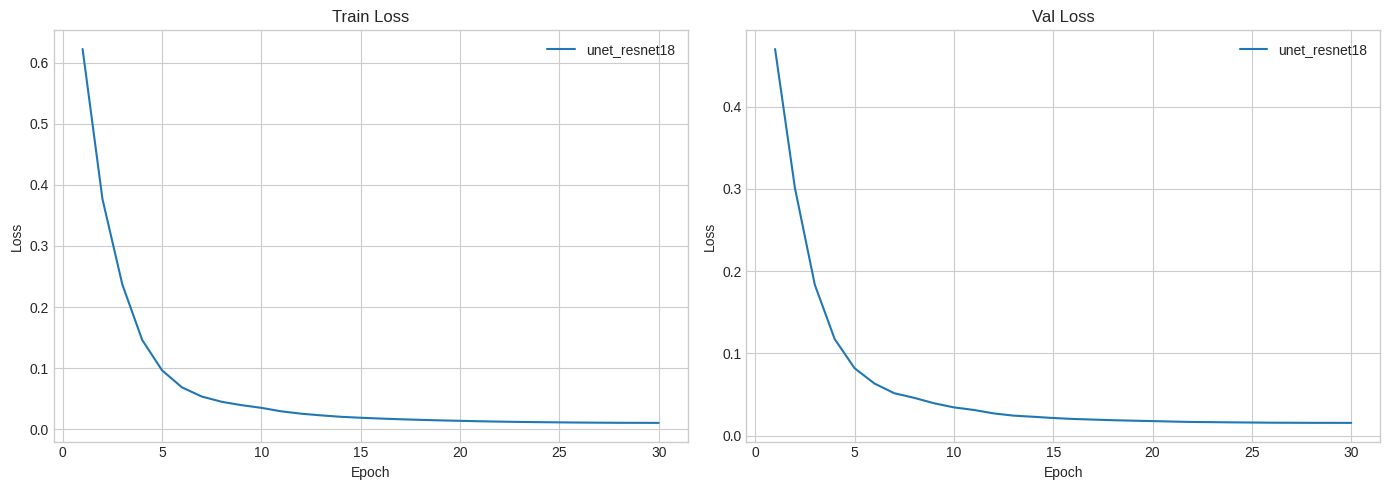

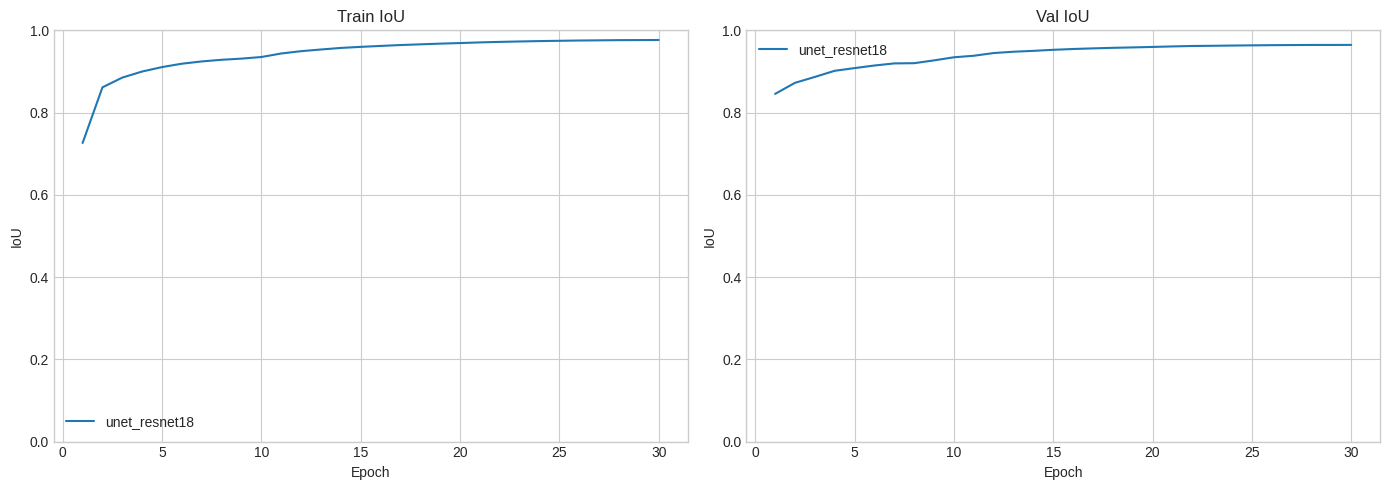

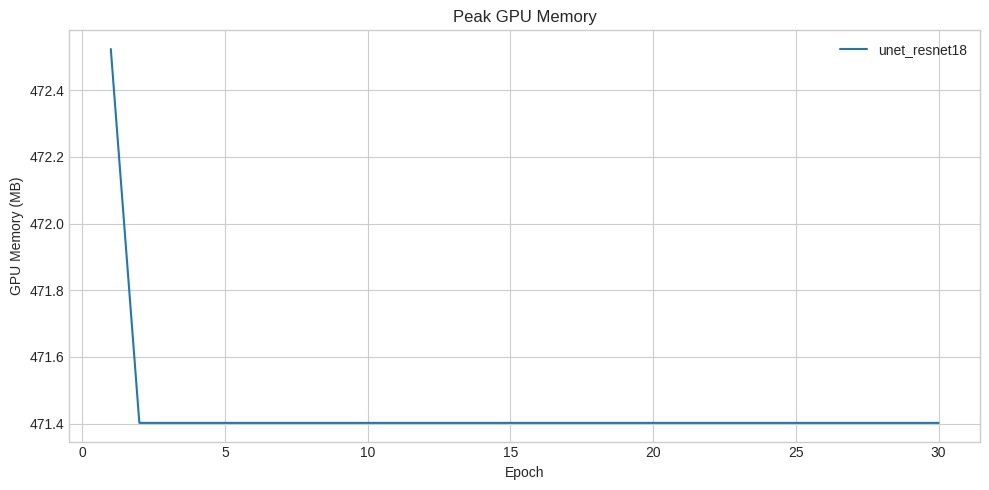

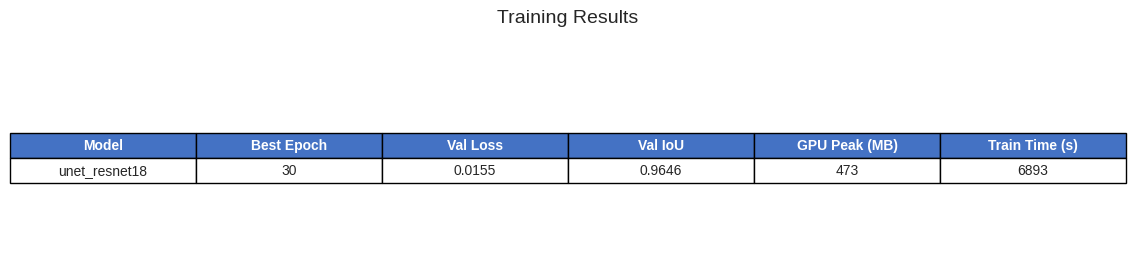

 All plots saved to /kaggle/working/outputs/results/plots


In [18]:
# Step 5 : Visualize & Compare Results

# Only ResNet has full epoch-level histories;
# YOLO histories have summary-level data only
histories = {'unet_resnet18': history_resnet}

# For YOLO, print summary
print("\n" + "="*60)
print("Training Summary")
print("="*60)
for name, h in [('unet_resnet18', history_resnet),
                ('yolov8m_seg', history_yolo8),
                ('yolov11m_seg', history_yolo11)]:
    print(f"  {name}: Best IoU={h.best_val_iou:.4f} @ epoch {h.best_epoch}, "
          f"GPU Peak={h.peak_gpu_memory_mb:.0f}MB, "
          f"Time={h.total_train_time_sec:.0f}s")

# Generate plots for ResNet (has epoch-level data)
if history_resnet.train_epochs:
    viz = TrainingVisualizer(str(PLOTS_DIR))
    viz.generate_all(histories)


## 7. Test Set Inference Visualization

Visual verification of trained models on previously unseen test samples.

In [ ]:
def visualize_test_results(num_samples=3):
    print(f"\n Visualizing {num_samples} samples from Test Set...")
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    # 1. Load UNet Best Model
    model_unet = UNetResNet18(n_classes=NUM_CLASSES, pretrained=False).to(device)
    unet_path = RESULTS_DIR / "checkpoints/unet_resnet18/best_model.pth"
    if unet_path.exists():
        ckpt = torch.load(unet_path, map_location=device)
        new_state_dict = {k.replace("module.", ""): v for k, v in ckpt["model_state_dict"].items()}
        model_unet.load_state_dict(new_state_dict)
        model_unet.eval()
        print("  UNet weights loaded.")
    
    # 2. Get Test Samples
    import random
    test_samples_paths = sorted(list((YOLO_DIR/"test"/"images").glob("*.png")) + list((YOLO_DIR/"test"/"images").glob("*.jpg")))
    if not test_samples_paths: return
    
    selected_paths = random.sample(test_samples_paths, min(num_samples, len(test_samples_paths)))
    
    # 4. Plotting
    cols = 2
    plt.figure(figsize=(10, 5 * len(selected_paths)))
    for idx, img_path in enumerate(selected_paths):
        img_bgr = cv2.imread(str(img_path))
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        
        plt.subplot(len(selected_paths), cols, idx * cols + 1)
        plt.imshow(img_rgb); plt.title(f"Sample {idx+1}: Input"); plt.axis("off")
        
        plt.subplot(len(selected_paths), cols, idx * cols + 2)
        with torch.no_grad():
            prep = cv2.resize(img_rgb, (512, 512))
            input_tensor = torch.from_numpy(prep).float().permute(2,0,1).unsqueeze(0).to(device) / 255.0
            out = model_unet(input_tensor)
            pred_mask = torch.argmax(out, dim=1).cpu().numpy()[0]
            pred_mask_res = cv2.resize(pred_mask.astype(np.uint8), (img_rgb.shape[1], img_rgb.shape[0]), interpolation=cv2.INTER_NEAREST)
        plt.imshow(img_rgb)
        plt.imshow(pred_mask_res, alpha=0.5, cmap="magma")
        plt.title(f"Sample {idx+1}: UNet Pred"); plt.axis("off")
            
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / "test_set_visual_verification.png", dpi=150)
    plt.show()

if "ted" in globals() or os.path.exists(YOLO_DIR/"test"/"images"):
    visualize_test_results(num_samples=4)


In [19]:
# Step 6 : Verify Output Structure

print("\n Output directory structure:")
for root, dirs, files in os.walk(str(OUTPUT_DIR)):
    level = root.replace(str(OUTPUT_DIR), '').count(os.sep)
    indent = ' ' * 2 * level
    print(f'{indent}{os.path.basename(root)}/')
    if level < 3:
        subindent = ' ' * 2 * (level + 1)
        for f in files[:5]:
            print(f'{subindent}{f}')
        if len(files) > 5:
            print(f'{subindent}... and {len(files)-5} more files')

print(f"\n All outputs saved to {OUTPUT_DIR}")
print("Download the outputs/ folder from Kaggle to sync with your local project.")



 Output directory structure:
outputs/
  augmented_data/
    run_020_00012_rot180_clean.png
    v3_run_022_00001_rot270_gamma_bright.json
    v2_run_017_00003_rot180_gamma_dark.png
    v3_run_021_00013_orig_gamma_bright.png
    v3_run_011_00009_rot90_clean.png
    ... and 31135 more files
  results/
    checkpoints/
      unet_resnet18/
    yolo_training/
      yolov8m_seg/
        weights/
      yolov11m_seg/
        weights/
    training_logs/
      yolov8m_seg/
      unet_resnet18/
      yolov11m_seg/
    plots/
      gpu_usage.png
      loss_curves.png
      iou_curves.png
      comparison_table.png
  yolo_dataset/
    data.yaml
    train/
      labels.cache
      labels/
      images/
    test/
      labels/
      images/
    val/
      labels.cache
      labels/
      images/

 All outputs saved to /kaggle/working/outputs
Download the outputs/ folder from Kaggle to sync with your local project.
